# 08 - Thesis Evidence Synthesis Across IEEE-CIS and BAF

In [1]:
from pathlib import Path
import hashlib
import json
import os
import subprocess
import sys

KAGGLE = Path("/kaggle").exists()
REPO_URL = "https://github.com/Tommyhuy1705/Explainable_NeuroSymbolic_Fraud_Detection.git"
KAGGLE_PROJECT_DIR = Path("/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection")

if KAGGLE:
    os.environ.setdefault("THESIS_QUICK_RUN", "0")
    os.environ.setdefault("THESIS_SYNTHETIC_FALLBACK", "0")

def sync_kaggle_project() -> Path:
    """Use one current working clone; never import source bundled in an input artifact."""
    if not KAGGLE_PROJECT_DIR.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(KAGGLE_PROJECT_DIR)],
            check=True,
        )
    else:
        if not (KAGGLE_PROJECT_DIR / ".git").is_dir():
            raise RuntimeError(
                f"Kaggle project path exists but is not a Git clone: {KAGGLE_PROJECT_DIR}"
            )
        subprocess.run(
            ["git", "-C", str(KAGGLE_PROJECT_DIR), "pull", "--ff-only", "origin", "main"],
            check=True,
        )
    return KAGGLE_PROJECT_DIR.resolve()

def find_project_root() -> Path | None:
    direct_candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in direct_candidates:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate.resolve()
    return None

PROJECT_ROOT = sync_kaggle_project() if KAGGLE else find_project_root()
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project root with src/ and configs/ was not found")

project_root_string = str(PROJECT_ROOT)
while project_root_string in sys.path:
    sys.path.remove(project_root_string)
sys.path.insert(0, project_root_string)

# Run All can reuse a live Kaggle kernel. Remove previously imported project
# modules so an updated working clone cannot be shadowed by stale objects.
for module_name in tuple(sys.modules):
    if module_name == "src" or module_name.startswith("src."):
        del sys.modules[module_name]

AUDIT_SOURCE_FILES = (
    "scripts/generate_notebooks.py",
    "src/artifacts.py",
    "src/data/dataset.py",
    "src/data/preprocessing.py",
    "src/experiment.py",
    "src/explanation/explanation_metrics.py",
    "src/explanation/rule_explainer.py",
    "src/logic/fraud_rules.py",
    "src/logic/knowledge_base.py",
    "src/logic/predicates.py",
    "src/logic/tensor_logic.py",
)

def audit_pipeline_fingerprint(config_path: Path) -> str:
    paths = [PROJECT_ROOT / relative for relative in AUDIT_SOURCE_FILES]
    paths.append(Path(config_path))
    missing = [str(path) for path in paths if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Files required for the audit-pipeline fingerprint are missing: {missing}")
    digest = hashlib.sha256()
    for path in sorted(paths, key=lambda item: item.relative_to(PROJECT_ROOT).as_posix()):
        relative = path.relative_to(PROJECT_ROOT).as_posix()
        digest.update(relative.encode("utf-8"))
        digest.update(b"\0")
        digest.update(path.read_bytes())
        digest.update(b"\0")
    return digest.hexdigest()

QUICK_RUN = os.getenv("THESIS_QUICK_RUN", "0") == "1"
ALLOW_SYNTHETIC_FALLBACK = os.getenv("THESIS_SYNTHETIC_FALLBACK", "0") == "1"
OUTPUT_BASE = Path("/kaggle/working/thesis_outputs") if KAGGLE else PROJECT_ROOT / "results/runs/notebooks"
INPUT_ROOTS = [OUTPUT_BASE, PROJECT_ROOT / "results/runs/notebooks"]
if Path("/kaggle/input").exists():
    INPUT_ROOTS.append(Path("/kaggle/input"))

try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"], text=True
    ).strip()
except (OSError, subprocess.CalledProcessError):
    GIT_COMMIT = None

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
print({
    "project_root": str(PROJECT_ROOT),
    "project_source_policy": "working_clone_main" if KAGGLE else "local_project_root",
    "git_commit": GIT_COMMIT,
    "quick_run": QUICK_RUN,
    "synthetic_fallback": ALLOW_SYNTHETIC_FALLBACK,
    "kaggle": KAGGLE,
})

Cloning into '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection'...


{'project_root': '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection', 'project_source_policy': 'working_clone_main', 'git_commit': '7f52db0798667f23699e343372a8d08312789859', 'quick_run': False, 'synthetic_fallback': False, 'kaggle': True}


## Thiết lập

Notebook tổng hợp CSV/JSON từ các notebook trước, không train model và không thay đổi threshold.
Attach outputs mới nhất của Notebook 02-07 bằng Add Input khi chạy trên Kaggle. Reference model
luôn được đọc từ frozen manifest đã chọn bằng validation; test không được dùng để chọn lại model,
calibration, threshold hoặc rule subset.

In [2]:
from src.artifacts import (
    find_result_file, load_frozen_reference_artifact, sha256_file, stable_config_hash,
)
from src.data import load_config
from src.evaluation import expected_calibration_error
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score, brier_score_loss, confusion_matrix,
    log_loss, precision_recall_curve,
)

ieee_config_path = PROJECT_ROOT / "configs/ieee_cis.yaml"
baf_config_path = PROJECT_ROOT / "configs/baf.yaml"
ieee_config = load_config(ieee_config_path)
baf_config = load_config(baf_config_path)
ieee_artifact = load_frozen_reference_artifact("ieee_cis", expected_config=ieee_config, search_roots=INPUT_ROOTS)
baf_artifact = load_frozen_reference_artifact("baf", expected_config=baf_config, search_roots=INPUT_ROOTS)
artifacts = {"IEEE-CIS": ieee_artifact, "BAF": baf_artifact}
configs = {"IEEE-CIS": ieee_config, "BAF": baf_config}
config_paths = {"IEEE-CIS": ieee_config_path, "BAF": baf_config_path}
for dataset, frozen in artifacts.items():
    if bool(frozen["manifest"]["quick_run"]) != QUICK_RUN:
        raise ValueError(f"{dataset} frozen artifact mode does not match Notebook 08")
    if int(frozen["manifest"]["reference_seed"]) != int(configs[dataset]["evaluation"]["reference_seed"]):
        raise ValueError(f"{dataset} frozen artifact reference seed violates the locked protocol")
    if not QUICK_RUN and str(frozen["manifest"].get("data_source", "")).lower() == "synthetic":
        raise ValueError(f"{dataset} uses a synthetic-fallback artifact and cannot support final thesis claims")

ieee_benchmark_root = ieee_artifact["manifest_path"].parent
baf_benchmark_root = baf_artifact["manifest_path"].parent
output_dir = OUTPUT_BASE / "08_cross_dataset_result_synthesis"
output_dir.mkdir(parents=True, exist_ok=True)

required = {
    "ieee_predictive": ieee_benchmark_root / "predictive_metrics_summary.csv",
    "baf_predictive": baf_benchmark_root / "predictive_metrics_summary.csv",
    "ieee_bootstrap": ieee_benchmark_root / "paired_bootstrap_model_differences.csv",
    "baf_bootstrap": baf_benchmark_root / "paired_bootstrap_model_differences.csv",
    "ieee_rules": find_result_file("ieee_rule_quality.csv", INPUT_ROOTS, "04_ieee_cis_ltn_rule_analysis"),
    "ieee_satisfaction": find_result_file("ieee_knowledge_base_satisfaction.csv", INPUT_ROOTS, "04_ieee_cis_ltn_rule_analysis"),
    "ieee_stability": find_result_file("ieee_rule_stability.csv", INPUT_ROOTS, "04_ieee_cis_ltn_rule_analysis"),
    "ieee_thresholds": find_result_file("ieee_fitted_rule_thresholds.csv", INPUT_ROOTS, "04_ieee_cis_ltn_rule_analysis"),
    "ieee_rationale": find_result_file("ieee_rule_rationale.csv", INPUT_ROOTS, "04_ieee_cis_ltn_rule_analysis"),
    "ieee_rule_lineage": find_result_file("upstream_lineage.json", INPUT_ROOTS, "04_ieee_cis_ltn_rule_analysis"),
    "ieee_explanations": find_result_file("ieee_explanation_quality.csv", INPUT_ROOTS, "05_ieee_cis_rule_explanation_evaluation"),
    "ieee_explanation_lineage": find_result_file("upstream_lineage.json", INPUT_ROOTS, "05_ieee_cis_rule_explanation_evaluation"),
    "ieee_ablation": find_result_file("ieee_rule_ablation.csv", INPUT_ROOTS, "06_ieee_cis_rule_ablation"),
    "ieee_ablation_lineage": find_result_file("upstream_lineage.json", INPUT_ROOTS, "06_ieee_cis_rule_ablation"),
    "baf_rules": find_result_file("baf_rule_quality.csv", INPUT_ROOTS, "07_baf_ltn_generalization"),
    "baf_explanations": find_result_file("baf_explanation_quality.csv", INPUT_ROOTS, "07_baf_ltn_generalization"),
    "baf_satisfaction": find_result_file("baf_knowledge_base_satisfaction.csv", INPUT_ROOTS, "07_baf_ltn_generalization"),
    "baf_stability": find_result_file("baf_rule_stability.csv", INPUT_ROOTS, "07_baf_ltn_generalization"),
    "baf_thresholds": find_result_file("baf_fitted_rule_thresholds.csv", INPUT_ROOTS, "07_baf_ltn_generalization"),
    "baf_rationale": find_result_file("baf_rule_rationale.csv", INPUT_ROOTS, "07_baf_ltn_generalization"),
    "baf_replication_lineage": find_result_file("upstream_lineage.json", INPUT_ROOTS, "07_baf_ltn_generalization"),
}
missing = [str(path) for path in required.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Required upstream outputs are missing: {missing}")

manifest_items = {
    **required,
    "ieee_frozen_manifest": ieee_artifact["manifest_path"],
    "ieee_frozen_artifact": ieee_artifact["artifact_path"],
    "baf_frozen_manifest": baf_artifact["manifest_path"],
    "baf_frozen_artifact": baf_artifact["artifact_path"],
}
input_manifest = pd.DataFrame([
    {
        "artifact": name,
        "path": str(path),
        "sha256": sha256_file(path),
        "size_bytes": path.stat().st_size,
    }
    for name, path in manifest_items.items()
])
display(input_manifest)
input_manifest.to_csv(output_dir / "input_artifact_manifest.csv", index=False)

lineage_specs = [
    {
        "dataset": "IEEE-CIS", "stage": "04", "path": required["ieee_rule_lineage"],
        "notebook_id": "04_IEEE_CIS_LTN_Rule_Analysis", "frozen": None,
    },
    {
        "dataset": "IEEE-CIS", "stage": "05", "path": required["ieee_explanation_lineage"],
        "notebook_id": "05_IEEE_CIS_Rule_Explanation_Evaluation", "frozen": ieee_artifact,
    },
    {
        "dataset": "IEEE-CIS", "stage": "06", "path": required["ieee_ablation_lineage"],
        "notebook_id": "06_IEEE_CIS_Rule_Ablation", "frozen": ieee_artifact,
    },
    {
        "dataset": "BAF", "stage": "07", "path": required["baf_replication_lineage"],
        "notebook_id": "07_BAF_Cross_Dataset_Rule_and_Explanation_Replication", "frozen": baf_artifact,
    },
]
lineage_rows = []
for spec in lineage_specs:
    dataset = spec["dataset"]
    lineage_path = spec["path"]
    frozen = spec["frozen"]
    payload = json.loads(lineage_path.read_text(encoding="utf-8"))
    output_files = list(payload.get("output_files", []))
    output_hashes = dict(payload.get("output_sha256", {}))
    outputs_present = bool(output_files) and all(
        (lineage_path.parent / name).is_file() for name in output_files
    )
    outputs_hash_bound = (
        outputs_present
        and set(output_files) == set(output_hashes)
        and all(
            sha256_file(lineage_path.parent / name) == output_hashes[name]
            for name in output_files
        )
    )
    checks = {
        "notebook_match": payload.get("notebook_id") == spec["notebook_id"],
        "dataset_match": str(payload.get("dataset_name", "")).lower() == str(configs[dataset]["dataset"]["name"]).lower(),
        "config_match": payload.get("config_sha256") == stable_config_hash(configs[dataset]),
        "source_fingerprint_match": payload.get("audit_source_sha256") == audit_pipeline_fingerprint(config_paths[dataset]),
        "manifest_match": (
            True if frozen is None else
            payload.get("frozen_manifest_sha256") == sha256_file(frozen["manifest_path"])
        ),
        "artifact_match": (
            True if frozen is None else
            payload.get("frozen_artifact_sha256") == sha256_file(frozen["artifact_path"])
        ),
        "reference_seed_match": (
            True if frozen is None else
            int(payload.get("reference_seed", -1)) == int(configs[dataset]["evaluation"]["reference_seed"])
        ),
        "mode_match": bool(payload.get("quick_run")) == QUICK_RUN,
        "data_source_acceptable": QUICK_RUN or str(payload.get("data_source", "")).lower() != "synthetic",
        "declared_outputs_present": outputs_present,
        "output_hashes_match": outputs_hash_bound,
    }
    lineage_rows.append({
        "dataset": dataset, "stage": spec["stage"],
        "git_commit": payload.get("git_commit"), "lineage": str(lineage_path), **checks,
    })
lineage_audit = pd.DataFrame(lineage_rows)
display(lineage_audit)
audit_checks = lineage_audit.drop(columns=["dataset", "stage", "git_commit", "lineage"])
if not audit_checks.all(axis=None):
    raise ValueError("At least one Notebook 04-07 output failed provenance or alignment checks")
lineage_audit.to_csv(output_dir / "upstream_lineage_audit.csv", index=False)

,artifact,path,sha256,size_bytes
0,ieee_predictive,/kaggle/input/notebooks/giahuytranviet/02-ieee-cis-model-benchmarks-ipynb/thesis_outputs/02_ieee_cis_model_benchmark...,7eb08f69930a97534868cf9c7d1a1cc35aedb3ca408606e94284fee58e9e4150,3701
1,baf_predictive,/kaggle/input/notebooks/giahuytranviet/03-baf-model-benchmarks/thesis_outputs/03_baf_model_benchmarks/predictive_met...,c9e4780a3e6ca98a3c74fc1e6deb8679756cbf272bb2508b26c214efdf0a34fe,3732
2,ieee_bootstrap,/kaggle/input/notebooks/giahuytranviet/02-ieee-cis-model-benchmarks-ipynb/thesis_outputs/02_ieee_cis_model_benchmark...,4b63a1d2080eb715fad5e9859c6479c29348d8466c62db8f2779c37edbc0958b,383
3,baf_bootstrap,/kaggle/input/notebooks/giahuytranviet/03-baf-model-benchmarks/thesis_outputs/03_baf_model_benchmarks/paired_bootstr...,3a163c644c02b2d4b3d422412f23bc5a2d369b0ffaed3acd8d0be3b84a38f350,386
4,ieee_rules,/kaggle/input/notebooks/giahuytranviet/04-ieee-cis-ltn-style-fraud-rule-analysis/thesis_outputs/04_ieee_cis_ltn_rule...,b4254b46b233a10e01c134af837b22dcf4de24ec2f3ec9dcc9b53c76e9a6d40d,2136
5,ieee_satisfaction,/kaggle/input/notebooks/giahuytranviet/04-ieee-cis-ltn-style-fraud-rule-analysis/thesis_outputs/04_ieee_cis_ltn_rule...,1c23dd5a22e76af2f4eeaf0e4f26a0a9dd2a424a8a842b5cc74676d797747180,342
6,ieee_stability,/kaggle/input/notebooks/giahuytranviet/04-ieee-cis-ltn-style-fraud-rule-analysis/thesis_outputs/04_ieee_cis_ltn_rule...,174875b0ab55612ef894d6e98ef86d066074614b7fa572623bf188dd5ca74e01,1787
7,ieee_thresholds,/kaggle/input/notebooks/giahuytranviet/04-ieee-cis-ltn-style-fraud-rule-analysis/thesis_outputs/04_ieee_cis_ltn_rule...,dd9e108a3ad56f2eeaa91733a2f08795e5cb1a90d223bca612be047553cad830,687
8,ieee_rationale,/kaggle/input/notebooks/giahuytranviet/04-ieee-cis-ltn-style-fraud-rule-analysis/thesis_outputs/04_ieee_cis_ltn_rule...,7657d593d632c4cdc644e9826eb266ea009584461d65fc27fa90653d2ad9428e,1417
9,ieee_rule_lineage,/kaggle/input/notebooks/giahuytranviet/04-ieee-cis-ltn-style-fraud-rule-analysis/thesis_outputs/04_ieee_cis_ltn_rule...,6dd19b749e6719a2bf45e1c52e72d71bbc603d9e13ef2631f0a68fe3c873a6bc,1262


,dataset,stage,git_commit,lineage,notebook_match,dataset_match,config_match,source_fingerprint_match,manifest_match,artifact_match,reference_seed_match,mode_match,data_source_acceptable,declared_outputs_present,output_hashes_match
0,IEEE-CIS,04,5912ec86e8a37945e5aee8dad02ea738fd1e5161,/kaggle/input/notebooks/giahuytranviet/04-ieee-cis-ltn-style-fraud-rule-analysis/thesis_outputs/04_ieee_cis_ltn_rule...,True,True,True,True,True,True,True,True,True,True,True
1,IEEE-CIS,05,5912ec86e8a37945e5aee8dad02ea738fd1e5161,/kaggle/input/notebooks/giahuytranviet/05-ieee-cis-rule-explanation-evaluation/thesis_outputs/05_ieee_cis_rule_expla...,True,True,True,True,True,True,True,True,True,True,True
2,IEEE-CIS,06,5912ec86e8a37945e5aee8dad02ea738fd1e5161,/kaggle/input/notebooks/giahuytranviet/06-ieee-cis-rule-ablation/thesis_outputs/06_ieee_cis_rule_ablation/upstream_l...,True,True,True,True,True,True,True,True,True,True,True
3,BAF,07,1c833b23e6ce4f00c49513e79ad7f7715615986a,/kaggle/input/notebooks/giahuytranviet/07-baf-ltn-generalization/thesis_outputs/07_baf_ltn_generalization/upstream_l...,True,True,True,True,True,True,True,True,True,True,True


## Predictive evidence

In [3]:
predictive = pd.concat([
    pd.read_csv(required["ieee_predictive"]).assign(dataset="IEEE-CIS"),
    pd.read_csv(required["baf_predictive"]).assign(dataset="BAF"),
], ignore_index=True)
predictive_test = predictive.query("split == 'test'").copy()
reference_keys = {
    "IEEE-CIS": ieee_artifact["manifest"]["model_key"],
    "BAF": baf_artifact["manifest"]["model_key"],
}
reference_rows = pd.concat([
    predictive.loc[
        (predictive["dataset"] == dataset)
        & (predictive["model_key"] == model_key)
        & (predictive["split"] == "test")
    ]
    for dataset, model_key in reference_keys.items()
], ignore_index=True)
if len(reference_rows) != len(reference_keys):
    raise ValueError("Frozen reference model rows are missing or duplicated in predictive summaries")
prevalence = {
    dataset: float(frozen["y_test"].mean()) for dataset, frozen in artifacts.items()
}
reference_rows["test_prevalence"] = reference_rows["dataset"].map(prevalence)
reference_rows["pr_auc_over_prevalence"] = (
    reference_rows["raw_pr_auc_mean"] / reference_rows["test_prevalence"]
)

reference_split = predictive.loc[
    predictive.apply(lambda row: row["model_key"] == reference_keys[row["dataset"]], axis=1)
].copy()
reference_gap = reference_split.pivot(
    index=["dataset", "model", "model_key"], columns="split", values="raw_pr_auc_mean"
).reset_index()
reference_gap["validation_to_test_gap"] = reference_gap["test"] - reference_gap["validation"]

display(predictive_test.round(4), reference_rows.round(4), reference_gap.round(4))
predictive_test.to_csv(output_dir / "table_cross_dataset_predictive_test.csv", index=False)
reference_rows.to_csv(output_dir / "table_frozen_reference_predictive_test.csv", index=False)
reference_gap.to_csv(output_dir / "table_validation_to_test_gap.csv", index=False)

bootstrap = pd.concat([
    pd.read_csv(required["ieee_bootstrap"]).assign(dataset="IEEE-CIS"),
    pd.read_csv(required["baf_bootstrap"]).assign(dataset="BAF"),
], ignore_index=True)
bootstrap["uncertainty_scope"] = "paired row-level bootstrap on frozen reference-seed predictions"
display(bootstrap.round(5))
bootstrap.to_csv(output_dir / "table_cross_dataset_predictive_bootstrap.csv", index=False)

confusion_rows = []
calibration_rows = []
for dataset, frozen in artifacts.items():
    labels = frozen["y_test"].astype(int)
    raw_probability = frozen["test_raw_probability"].astype(float)
    calibrated_probability = frozen["test_probability"].astype(float)
    decision_threshold = float(frozen["manifest"]["threshold"])
    tn, fp, fn, tp = confusion_matrix(
        labels, calibrated_probability >= decision_threshold, labels=[0, 1]
    ).ravel()
    confusion_rows.append({
        "dataset": dataset, "threshold": decision_threshold,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "predicted_alert_count": int(fp + tp), "test_rows": len(labels),
    })
    for probability_type, probability in (
        ("raw", raw_probability), ("calibrated", calibrated_probability)
    ):
        calibration_rows.append({
            "dataset": dataset,
            "probability_type": probability_type,
            "pr_auc": average_precision_score(labels, probability),
            "brier": brier_score_loss(labels, probability),
            "ece": expected_calibration_error(labels, probability, n_bins=15),
            "nll": log_loss(labels, np.clip(probability, 1e-7, 1 - 1e-7), labels=[0, 1]),
        })
confusion_table = pd.DataFrame(confusion_rows)
calibration_table = pd.DataFrame(calibration_rows)
display(confusion_table, calibration_table.round(5))
confusion_table.to_csv(output_dir / "table_frozen_reference_confusion_counts.csv", index=False)
calibration_table.to_csv(output_dir / "table_raw_vs_calibrated_probability_metrics.csv", index=False)

,model,model_key,split,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fbeta_mean,fbeta_std,brier_mean,brier_std,ece_mean,ece_std,nll_mean,nll_std,threshold_mean,threshold_std,positive_rate_mean,positive_rate_std,raw_pr_auc_mean,raw_pr_auc_std,raw_roc_auc_mean,raw_roc_auc_std,n_seeds,dataset
0,MLP,mlp,test,0.3465,0.0114,0.8089,0.0053,0.2561,0.0460,0.5299,0.0357,0.3422,0.0325,0.4327,0.0057,0.0268,0.0003,0.0046,0.0019,0.1176,0.0036,0.0808,0.0081,0.0741,0.0171,0.3606,0.0162,0.8095,0.0049,3,IEEE-CIS
2,TabularResNet,tabular_resnet,test,0.3213,0.0183,0.7941,0.0054,0.2250,0.0312,0.5141,0.0104,0.3119,0.0274,0.4075,0.0144,0.0274,0.0006,0.0026,0.0008,0.1181,0.0023,0.0818,0.0133,0.0806,0.0119,0.3364,0.0181,0.7951,0.0057,3,IEEE-CIS
4,xgboost,tree,test,0.4407,0.0029,0.8667,0.0025,0.2545,0.0046,0.5819,0.0098,0.3541,0.0035,0.4628,0.0036,0.0244,0.0001,0.0076,0.0006,0.1058,0.0012,0.0849,0.0049,0.0796,0.0026,0.4557,0.0039,0.8672,0.0023,3,IEEE-CIS
6,MLP,mlp,test,0.1403,0.0054,0.8723,0.0007,0.1499,0.0126,0.4026,0.0281,0.2178,0.0098,0.3000,0.0025,0.0128,0.0000,0.0022,0.0003,0.0582,0.0003,0.0737,0.0115,0.0380,0.0060,0.1546,0.0034,0.8733,0.0005,3,BAF
8,TabularResNet,tabular_resnet,test,0.1260,0.0028,0.8615,0.0040,0.1354,0.0088,0.3994,0.0322,0.2017,0.0060,0.2864,0.0062,0.0129,0.0000,0.0022,0.0003,0.0596,0.0006,0.0698,0.0057,0.0417,0.0060,0.1369,0.0027,0.8624,0.0039,3,BAF
10,lightgbm,tree,test,0.1736,0.0009,0.8893,0.0015,0.1725,0.0086,0.4368,0.0264,0.2469,0.0044,0.3336,0.0062,0.0125,0.0000,0.0026,0.0004,0.0559,0.0003,0.0750,0.0119,0.0357,0.0039,0.1890,0.0019,0.8906,0.0007,3,BAF


,model,model_key,split,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fbeta_mean,fbeta_std,brier_mean,brier_std,ece_mean,ece_std,nll_mean,nll_std,threshold_mean,threshold_std,positive_rate_mean,positive_rate_std,raw_pr_auc_mean,raw_pr_auc_std,raw_roc_auc_mean,raw_roc_auc_std,n_seeds,dataset,test_prevalence,pr_auc_over_prevalence
0,xgboost,tree,test,0.4407,0.0029,0.8667,0.0025,0.2545,0.0046,0.5819,0.0098,0.3541,0.0035,0.4628,0.0036,0.0244,0.0001,0.0076,0.0006,0.1058,0.0012,0.0849,0.0049,0.0796,0.0026,0.4557,0.0039,0.8672,0.0023,3,IEEE-CIS,0.0348,13.0918
1,lightgbm,tree,test,0.1736,0.0009,0.8893,0.0015,0.1725,0.0086,0.4368,0.0264,0.2469,0.0044,0.3336,0.0062,0.0125,0.0000,0.0026,0.0004,0.0559,0.0003,0.0750,0.0119,0.0357,0.0039,0.1890,0.0019,0.8906,0.0007,3,BAF,0.0140,13.4653


split,dataset,model,model_key,test,validation,validation_to_test_gap
0,BAF,lightgbm,tree,0.1890,0.1899,-0.0009
1,IEEE-CIS,xgboost,tree,0.4557,0.5316,-0.0759


,reference_model_key,comparator_model_key,observed_difference,bootstrap_mean_difference,ci_low,ci_high,probability_a_better,bootstrap_iterations,bootstrap_rows,dataset,uncertainty_scope
0,tree,mlp,0.08680,0.08647,0.07444,0.10080,1.0,300.0,88581.0,IEEE-CIS,paired row-level bootstrap on frozen reference-seed predictions
1,tree,tabular_resnet,0.13689,0.13716,0.12071,0.15465,1.0,300.0,88581.0,IEEE-CIS,paired row-level bootstrap on frozen reference-seed predictions
2,tree,mlp,0.03507,0.03479,0.02608,0.04289,1.0,300.0,205011.0,BAF,paired row-level bootstrap on frozen reference-seed predictions
3,tree,tabular_resnet,0.05239,0.05211,0.04273,0.06057,1.0,300.0,205011.0,BAF,paired row-level bootstrap on frozen reference-seed predictions


,dataset,threshold,tn,fp,fn,tp,predicted_alert_count,test_rows
0,IEEE-CIS,0.088235,80453,5045,1324,1759,6804,88581
1,BAF,0.072464,195927,6206,1604,1274,7480,205011


,dataset,probability_type,pr_auc,brier,ece,nll
0,IEEE-CIS,raw,0.45253,0.04108,0.07720,0.16084
1,IEEE-CIS,calibrated,0.43740,0.02451,0.00830,0.10646
2,BAF,raw,0.18823,0.08444,0.17149,0.27405
3,BAF,calibrated,0.17435,0.01251,0.00275,0.05590


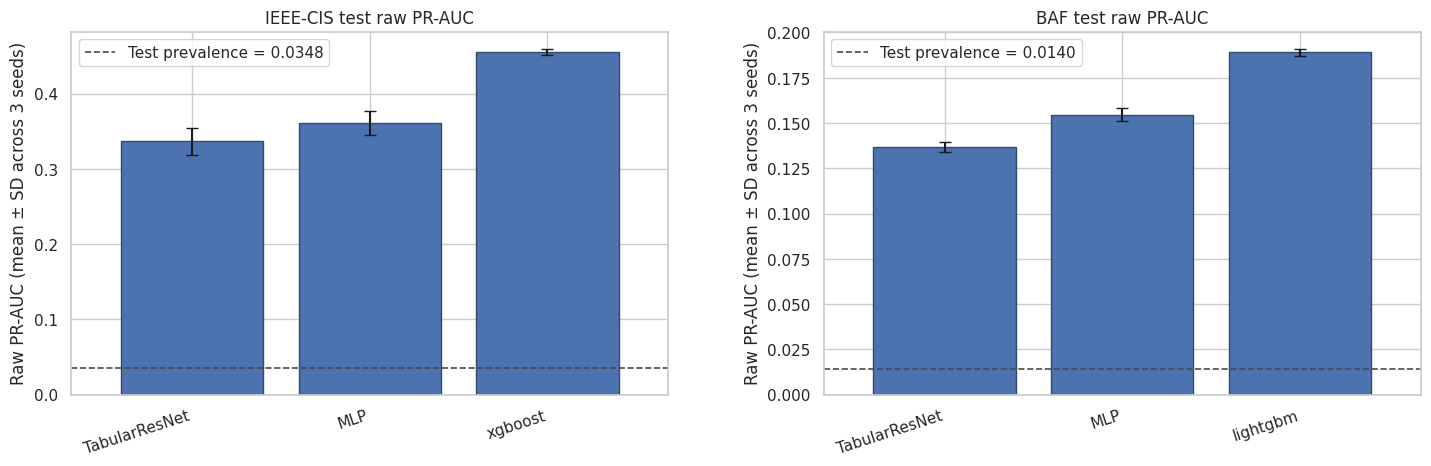

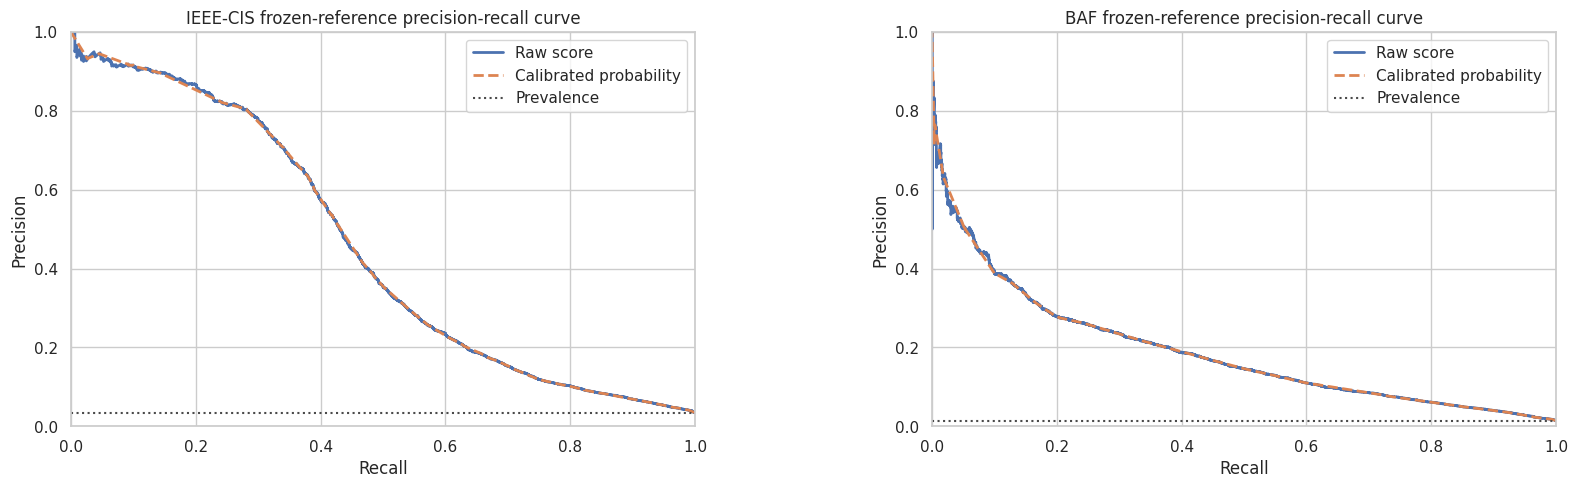

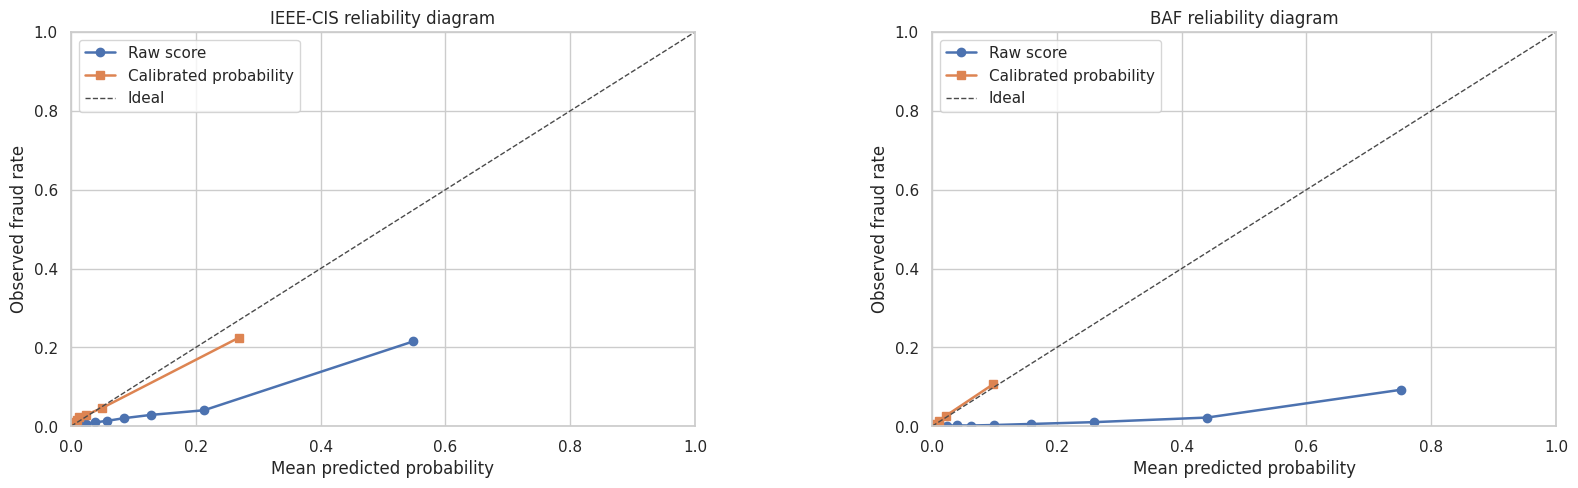

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=False)
model_color = "#4C72B0"
for axis, dataset in zip(axes, ("IEEE-CIS", "BAF")):
    subset = predictive_test.loc[predictive_test["dataset"] == dataset].sort_values("raw_pr_auc_mean")
    positions = np.arange(len(subset))
    axis.bar(
        positions, subset["raw_pr_auc_mean"],
        yerr=subset["raw_pr_auc_std"].fillna(0),
        color=model_color, edgecolor="#2F4B66", capsize=4,
    )
    axis.axhline(prevalence[dataset], color="#4A4A4A", linestyle="--", linewidth=1.2,
                 label=f"Test prevalence = {prevalence[dataset]:.4f}")
    axis.set_xticks(positions, subset["model"], rotation=18, ha="right")
    axis.set_title(f"{dataset} test raw PR-AUC")
    axis.set_ylabel("Raw PR-AUC (mean ± SD across 3 seeds)")
    axis.legend(loc="upper left")
    axis.margins(x=0.10)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.22, top=0.88, wspace=0.26)
fig.savefig(output_dir / "figure_predictive_performance_by_dataset.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.4))
for axis, (dataset, frozen) in zip(axes, artifacts.items()):
    labels = frozen["y_test"].astype(int)
    raw_probability = frozen["test_raw_probability"].astype(float)
    calibrated_probability = frozen["test_probability"].astype(float)
    for name, probability, color, line_style in (
        ("Raw score", raw_probability, "#4C72B0", "-"),
        ("Calibrated probability", calibrated_probability, "#DD8452", "--"),
    ):
        precision, recall, _ = precision_recall_curve(labels, probability)
        axis.plot(recall, precision, color=color, linestyle=line_style, linewidth=2, label=name)
    axis.axhline(prevalence[dataset], color="#4A4A4A", linestyle=":", label="Prevalence")
    axis.set_title(f"{dataset} frozen-reference precision-recall curve")
    axis.set_xlabel("Recall")
    axis.set_ylabel("Precision")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.legend(loc="upper right")
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.15, top=0.88, wspace=0.38)
fig.savefig(output_dir / "figure_frozen_reference_pr_curves.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.4))
for axis, (dataset, frozen) in zip(axes, artifacts.items()):
    labels = frozen["y_test"].astype(int)
    for name, probability, color, marker in (
        ("Raw score", frozen["test_raw_probability"], "#4C72B0", "o"),
        ("Calibrated probability", frozen["test_probability"], "#DD8452", "s"),
    ):
        observed, predicted = calibration_curve(labels, probability, n_bins=10, strategy="quantile")
        axis.plot(predicted, observed, color=color, marker=marker, linewidth=1.8, label=name)
    axis.plot([0, 1], [0, 1], color="#4A4A4A", linestyle="--", linewidth=1, label="Ideal")
    axis.set_title(f"{dataset} reliability diagram")
    axis.set_xlabel("Mean predicted probability")
    axis.set_ylabel("Observed fraud rate")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.legend(loc="upper left")
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.15, top=0.88, wspace=0.38)
fig.savefig(output_dir / "figure_frozen_reference_reliability.png", dpi=180, bbox_inches="tight")
plt.show()

## Rule, explanation and ablation evidence

In [5]:
rules = pd.concat([
    pd.read_csv(required["ieee_rules"]).assign(dataset="IEEE-CIS"),
    pd.read_csv(required["baf_rules"]).assign(dataset="BAF"),
], ignore_index=True)
explanations = pd.concat([
    pd.read_csv(required["ieee_explanations"]).assign(dataset="IEEE-CIS"),
    pd.read_csv(required["baf_explanations"]).assign(dataset="BAF"),
], ignore_index=True)
satisfaction = pd.concat([
    pd.read_csv(required["ieee_satisfaction"]).assign(dataset="IEEE-CIS"),
    pd.read_csv(required["baf_satisfaction"]).assign(dataset="BAF"),
], ignore_index=True)
stability = pd.concat([
    pd.read_csv(required["ieee_stability"]).assign(dataset="IEEE-CIS"),
    pd.read_csv(required["baf_stability"]).assign(dataset="BAF"),
], ignore_index=True)
fitted_thresholds = pd.concat([
    pd.read_csv(required["ieee_thresholds"]).assign(dataset="IEEE-CIS"),
    pd.read_csv(required["baf_thresholds"]).assign(dataset="BAF"),
], ignore_index=True)
rule_rationale = pd.concat([
    pd.read_csv(required["ieee_rationale"]).assign(dataset="IEEE-CIS"),
    pd.read_csv(required["baf_rationale"]).assign(dataset="BAF"),
], ignore_index=True)
ablation = pd.read_csv(required["ieee_ablation"])
display(
    rules.round(4), satisfaction.round(4), stability.round(4),
    explanations.round(4), ablation.round(4), fitted_thresholds, rule_rationale,
)
rules.to_csv(output_dir / "table_cross_dataset_rule_quality.csv", index=False)
satisfaction.to_csv(output_dir / "table_cross_dataset_knowledge_base_satisfaction.csv", index=False)
stability.to_csv(output_dir / "table_cross_dataset_rule_stability.csv", index=False)
explanations.to_csv(output_dir / "table_cross_dataset_explanation_quality.csv", index=False)
ablation.to_csv(output_dir / "table_ieee_rule_ablation.csv", index=False)
fitted_thresholds.to_csv(output_dir / "table_cross_dataset_fitted_rule_thresholds.csv", index=False)
rule_rationale.to_csv(output_dir / "table_cross_dataset_rule_rationale.csv", index=False)

,rule,evaluated_rows,coverage,active_count,fraud_precision,lift,mean_truth,rule_auc,split,dataset
0,high_amount_and_device_risk,413378,0.0014,593,0.3120,8.8707,0.0174,0.6494,train,IEEE-CIS
1,high_velocity_proxy,413378,0.0490,20249,0.0778,2.2131,0.0624,0.6169,train,IEEE-CIS
2,high_transaction_amount,413378,0.0424,17533,0.0422,1.2001,0.0727,0.4994,train,IEEE-CIS
3,unusual_transaction_hour,413378,0.2511,103818,0.0376,1.0698,0.3298,0.5324,train,IEEE-CIS
4,high_amount_and_email_risk,413378,0.0000,1,0.0000,0.0000,0.0028,0.6054,train,IEEE-CIS
5,high_amount_and_device_risk,88581,0.0008,75,0.6267,18.2481,0.0105,0.6678,validation,IEEE-CIS
6,high_amount_and_email_risk,88581,0.0000,2,0.5000,14.5597,0.0028,0.5770,validation,IEEE-CIS
7,high_velocity_proxy,88581,0.0542,4797,0.0930,2.7074,0.0680,0.5895,validation,IEEE-CIS
8,high_transaction_amount,88581,0.0418,3704,0.0613,1.7846,0.0719,0.5130,validation,IEEE-CIS
9,unusual_transaction_hour,88581,0.2276,20161,0.0393,1.1454,0.3074,0.5406,validation,IEEE-CIS


,split,overall_satisfaction,positive_satisfaction,negative_satisfaction,balanced_satisfaction,dataset
0,train,0.5941,0.4838,0.5981,0.5409,IEEE-CIS
1,validation,0.6126,0.4862,0.6171,0.5516,IEEE-CIS
2,test,0.6267,0.4500,0.6331,0.5415,IEEE-CIS
3,train,0.4794,0.5629,0.4786,0.5207,BAF
4,validation,0.4883,0.5534,0.4875,0.5204,BAF
5,test,0.4899,0.5393,0.4892,0.5142,BAF


,rule,evaluated_rows_validation,coverage_validation,active_count_validation,fraud_precision_validation,lift_validation,mean_truth_validation,rule_auc_validation,split_validation,evaluated_rows_test,coverage_test,active_count_test,fraud_precision_test,lift_test,mean_truth_test,rule_auc_test,split_test,coverage_delta,lift_delta,dataset
0,high_amount_and_device_risk,88581,0.0008,75,0.6267,18.2481,0.0105,0.6678,validation,88581,0.0008,73,0.6575,18.8923,0.0130,0.6798,test,-0.0000,0.6442,IEEE-CIS
1,high_amount_and_email_risk,88581,0.0000,2,0.5000,14.5597,0.0028,0.5770,validation,88581,0.0000,1,0.0000,0.0000,0.0028,0.5981,test,-0.0000,-14.5597,IEEE-CIS
2,high_velocity_proxy,88581,0.0542,4797,0.0930,2.7074,0.0680,0.5895,validation,88581,0.0465,4118,0.0746,2.1420,0.0603,0.6193,test,-0.0077,-0.5654,IEEE-CIS
3,high_transaction_amount,88581,0.0418,3704,0.0613,1.7846,0.0719,0.5130,validation,88581,0.0435,3857,0.0565,1.6240,0.0729,0.4732,test,0.0017,-0.1606,IEEE-CIS
4,unusual_transaction_hour,88581,0.2276,20161,0.0393,1.1454,0.3074,0.5406,validation,88581,0.2110,18687,0.0409,1.1762,0.2914,0.5343,test,-0.0166,0.0309,IEEE-CIS
5,foreign_high_limit_request,119323,0.0003,37,0.1892,15.9990,0.0024,0.5145,validation,205011,0.0004,74,0.2432,17.3272,0.0024,0.5137,test,0.0001,1.3281,BAF
6,device_email_linkage,119323,0.0151,1799,0.0650,5.4999,0.5054,0.5341,validation,205011,0.0133,2719,0.0585,4.1656,0.5044,0.5195,test,-0.0018,-1.3343,BAF
7,short_session_high_risk,119323,0.0225,2682,0.0246,2.0810,0.0687,0.4979,validation,205011,0.0199,4070,0.0334,2.3803,0.0636,0.4947,test,-0.0026,0.2992,BAF
8,high_velocity,119323,0.0041,486,0.0082,0.6960,0.0721,0.4702,validation,205011,0.0043,879,0.0114,0.8104,0.0482,0.4729,test,0.0002,0.1144,BAF
9,young_high_income_request,119323,0.0000,0,NaN,NaN,0.0910,0.3963,validation,205011,0.0000,0,NaN,NaN,0.0967,0.3848,test,0.0000,NaN,BAF


,test_rows,predicted_alert_count,non_alert_count,predicted_alert_fraud_count,explained_count,zero_rule_count,explained_alert_count,explained_alert_fraud_count,unsupported_alert_count,rule_evidence_without_alert_count,explanation_coverage_all,zero_rule_fraction,explanation_coverage_alerts,unsupported_alert_rate,rule_evidence_without_alert_rate,mean_rule_count,mean_active_rule_count,mean_displayed_rule_count,mean_active_rule_fraction,sparsity,rule_sparsity,prediction_rule_consistency,balanced_prediction_rule_consistency,contradiction_rate,explained_alert_precision,all_alert_precision,explained_alert_precision_gain,precision_gain_bootstrap_mean,precision_gain_ci_low,precision_gain_ci_high,bootstrap_valid_iterations,dataset
0,88581,6804,81777,1759,25162,63419,2642,795,4162,22520,0.2841,0.7159,0.3883,0.6117,0.2754,0.3018,0.3018,0.3018,0.0604,0.9396,0.9396,0.6988,0.5565,0.3012,0.3009,0.2585,0.0424,0.0425,0.0293,0.0567,1000.0,IEEE-CIS
1,205011,7480,197531,1274,7685,197326,861,192,6619,6824,0.0375,0.9625,0.1151,0.8849,0.0345,0.0378,0.0378,0.0378,0.0076,0.9924,0.9924,0.9344,0.5403,0.0656,0.2230,0.1703,0.0527,0.0525,0.0276,0.0777,1000.0,BAF


,ablation,activation_threshold,rule_count,analysis_role,test_rows,predicted_alert_count,explained_count,explained_alert_count,explained_alert_fraud_count,coverage_all,coverage_alerts,unsupported_alert_rate,rule_evidence_without_alert_rate,explained_alert_precision,all_alert_precision,precision_gain,prediction_rule_consistency,balanced_prediction_rule_consistency
0,full_rule_set,0.6,5,post_hoc_locked_test_diagnostic,88581,6804,25162,2642,795,0.2841,0.3883,0.6117,0.2754,0.3009,0.2585,0.0424,0.6988,0.5565
1,no_rules,0.6,0,post_hoc_locked_test_diagnostic,88581,6804,0,0,0,0.0000,0.0000,1.0000,0.0000,NaN,0.2585,NaN,0.9232,0.5000
2,only:high_transaction_amount,0.6,1,post_hoc_locked_test_diagnostic,88581,6804,3857,546,118,0.0435,0.0802,0.9198,0.0405,0.2161,0.2585,-0.0424,0.8920,0.5199
3,only:unusual_transaction_hour,0.6,1,post_hoc_locked_test_diagnostic,88581,6804,18687,1980,541,0.2110,0.2910,0.7090,0.2043,0.2732,0.2585,0.0147,0.7569,0.5434
4,only:high_amount_and_device_risk,0.6,1,post_hoc_locked_test_diagnostic,88581,6804,73,42,37,0.0008,0.0062,0.9938,0.0004,0.8810,0.2585,0.6224,0.9233,0.5029
5,only:high_amount_and_email_risk,0.6,1,post_hoc_locked_test_diagnostic,88581,6804,1,0,0,0.0000,0.0000,1.0000,0.0000,NaN,0.2585,NaN,0.9232,0.5000
6,only:high_velocity_proxy,0.6,1,post_hoc_locked_test_diagnostic,88581,6804,4118,306,244,0.0465,0.0450,0.9550,0.0466,0.7974,0.2585,0.5389,0.8836,0.4992
7,without:high_transaction_amount,0.6,4,post_hoc_locked_test_diagnostic,88581,6804,21872,2209,714,0.2469,0.3247,0.6753,0.2404,0.3232,0.2585,0.0647,0.7261,0.5421
8,without:unusual_transaction_hour,0.6,4,post_hoc_locked_test_diagnostic,88581,6804,7964,874,382,0.0899,0.1285,0.8715,0.0867,0.4371,0.2585,0.1785,0.8530,0.5209
9,without:high_amount_and_device_risk,0.6,4,post_hoc_locked_test_diagnostic,88581,6804,25147,2634,790,0.2839,0.3871,0.6129,0.2753,0.2999,0.2585,0.0414,0.6988,0.5559


,rule,feature,operator,configured_value,fitted_threshold,softness,softness_mode,fitted_missing_value,dataset
0,high_transaction_amount,TransactionAmt,greater_quantile,0.95,444.95,0.20,relative,68.950000,IEEE-CIS
1,unusual_transaction_hour,transaction_hour,outside_range,"[6.0, 23.0]","[6.0, 23.0]",1.50,absolute,16.000000,IEEE-CIS
2,high_amount_and_device_risk,TransactionAmt,greater_quantile,0.9,280.0,0.25,relative,68.950000,IEEE-CIS
3,high_amount_and_device_risk,DeviceType,category_risk,0.7,0.7,0.10,relative,NaN,IEEE-CIS
4,high_amount_and_email_risk,TransactionAmt,greater_quantile,0.9,280.0,0.25,relative,68.950000,IEEE-CIS
5,high_amount_and_email_risk,P_emaildomain,category_risk,0.7,0.7,0.10,relative,NaN,IEEE-CIS
6,high_velocity_proxy,C1,greater_quantile,0.95,22.0,0.20,relative,1.000000,IEEE-CIS
7,high_velocity,velocity_6h,greater_quantile,0.95,11914.976769,0.20,relative,6274.609077,BAF
8,device_email_linkage,device_distinct_emails_8w,greater_quantile,0.9,1.0,0.20,relative,1.000000,BAF
9,foreign_high_limit_request,foreign_request,equals,1.0,1.0,0.05,absolute,NaN,BAF


,rule,description,knowledge_type,threshold_source,limitation,dataset
0,high_transaction_amount,Transaction amount is unusually high.,domain hypothesis with train-fitted thresholds,training-split quantile,Association-based audit evidence; activation does not establish causality or model faithfulness.,IEEE-CIS
1,unusual_transaction_hour,Transaction occurs during an unusual time window.,configured domain hypothesis,explicit configured value,TransactionDT-derived cyclic phase; the unknown clock origin prevents a local-hour claim.,IEEE-CIS
2,high_amount_and_device_risk,A high-value transaction is associated with risky device metadata.,data-informed and train-fitted fuzzy hypothesis,train-label-smoothed category risk with configured cutoff plus training-split quantile,Association-based audit evidence; activation does not establish causality or model faithfulness.,IEEE-CIS
3,high_amount_and_email_risk,A high-value transaction uses an email domain with elevated fraud risk.,data-informed and train-fitted fuzzy hypothesis,train-label-smoothed category risk with configured cutoff plus training-split quantile,Association-based audit evidence; activation does not establish causality or model faithfulness.,IEEE-CIS
4,high_velocity_proxy,Transaction-count features indicate unusually high activity.,domain hypothesis with train-fitted thresholds,training-split quantile,Association-based audit evidence; activation does not establish causality or model faithfulness.,IEEE-CIS
5,high_velocity,Recent application velocity is unusually high.,domain hypothesis with train-fitted thresholds,training-split quantile plus any explicit configured condition,BAF-specific association; this rule is not transferred from IEEE-CIS and is not causal.,BAF
6,device_email_linkage,The device is linked to an unusually high number of email addresses.,domain hypothesis with train-fitted thresholds,training-split quantile plus any explicit configured condition,BAF-specific association; this rule is not transferred from IEEE-CIS and is not causal.,BAF
7,foreign_high_limit_request,A foreign request is associated with a high proposed credit limit.,domain hypothesis with train-fitted thresholds,training-split quantile plus any explicit configured condition,BAF-specific association; this rule is not transferred from IEEE-CIS and is not causal.,BAF
8,short_session_high_risk,A short application session has an elevated credit-risk score.,domain hypothesis with train-fitted thresholds,training-split quantile plus any explicit configured condition,BAF-specific association; this rule is not transferred from IEEE-CIS and is not causal.,BAF
9,young_high_income_request,A young applicant reports unusually high income.,domain hypothesis with train-fitted thresholds,training-split quantile plus any explicit configured condition,BAF-specific association; this rule is not transferred from IEEE-CIS and is not causal.,BAF


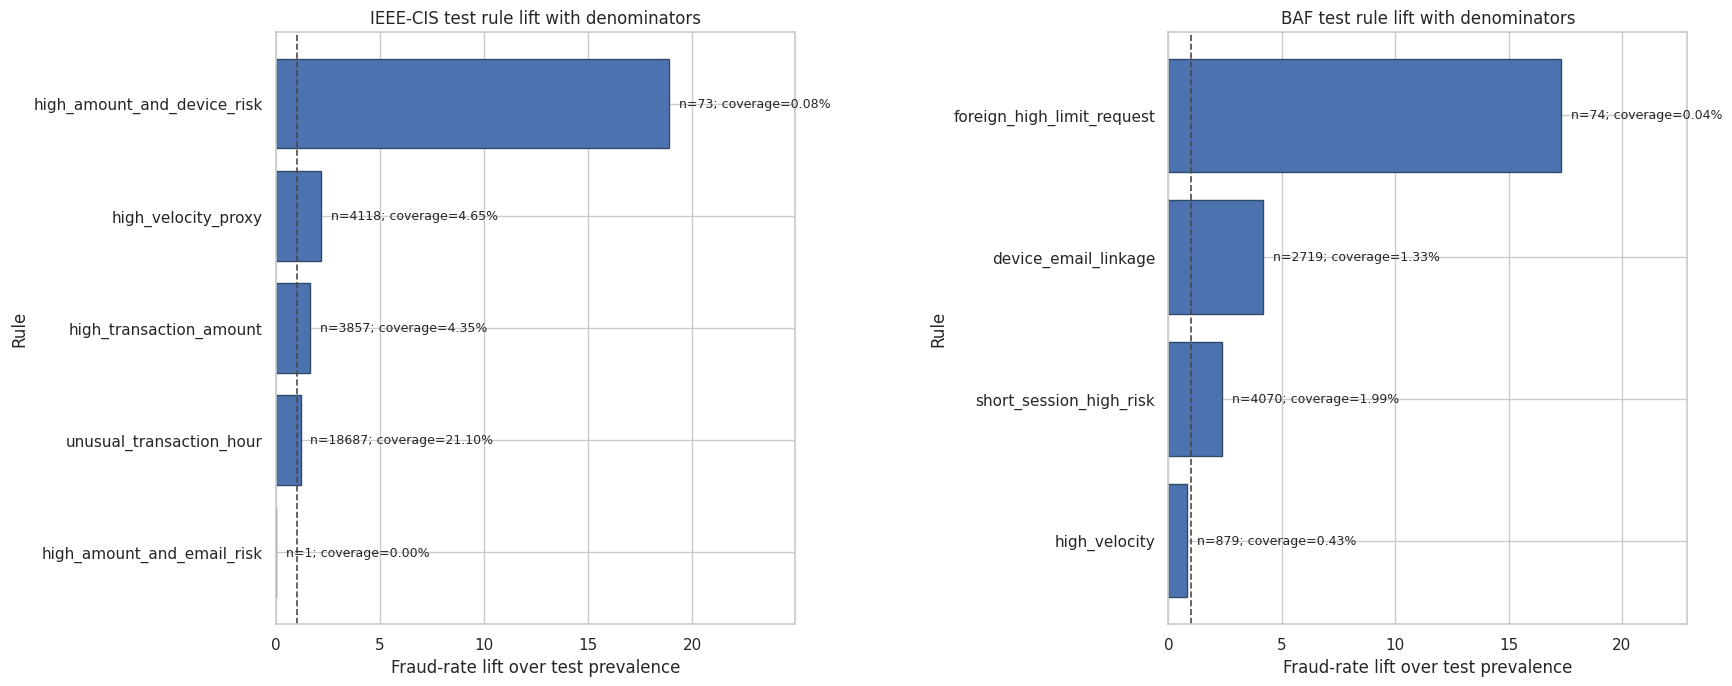

In [6]:
test_rules = rules.query("split == 'test'") if "split" in rules else rules
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
for axis, dataset in zip(axes, ("IEEE-CIS", "BAF")):
    subset = (
        test_rules.loc[(test_rules["dataset"] == dataset) & test_rules["lift"].notna()]
        .query("active_count > 0")
        .sort_values("lift")
    )
    positions = np.arange(len(subset))
    axis.barh(positions, subset["lift"], color="#4C72B0", edgecolor="#2F4B66")
    axis.set_yticks(positions, subset["rule"])
    axis.axvline(1.0, color="#4A4A4A", linestyle="--", linewidth=1.2)
    axis.set_title(f"{dataset} test rule lift with denominators")
    axis.set_xlabel("Fraud-rate lift over test prevalence")
    axis.set_ylabel("Rule")
    axis.set_xlim(0, max(1.2, float(subset["lift"].max()) * 1.32))
    for position, (_, row) in enumerate(subset.iterrows()):
        axis.text(
            row["lift"] + float(subset["lift"].max()) * 0.025,
            position,
            f"n={int(row['active_count'])}; coverage={row['coverage']:.2%}",
            va="center", fontsize=9,
        )
fig.subplots_adjust(left=0.15, right=0.98, bottom=0.11, top=0.90, wspace=0.72)
fig.savefig(output_dir / "figure_rule_lift_with_denominators.png", dpi=180, bbox_inches="tight")
plt.show()

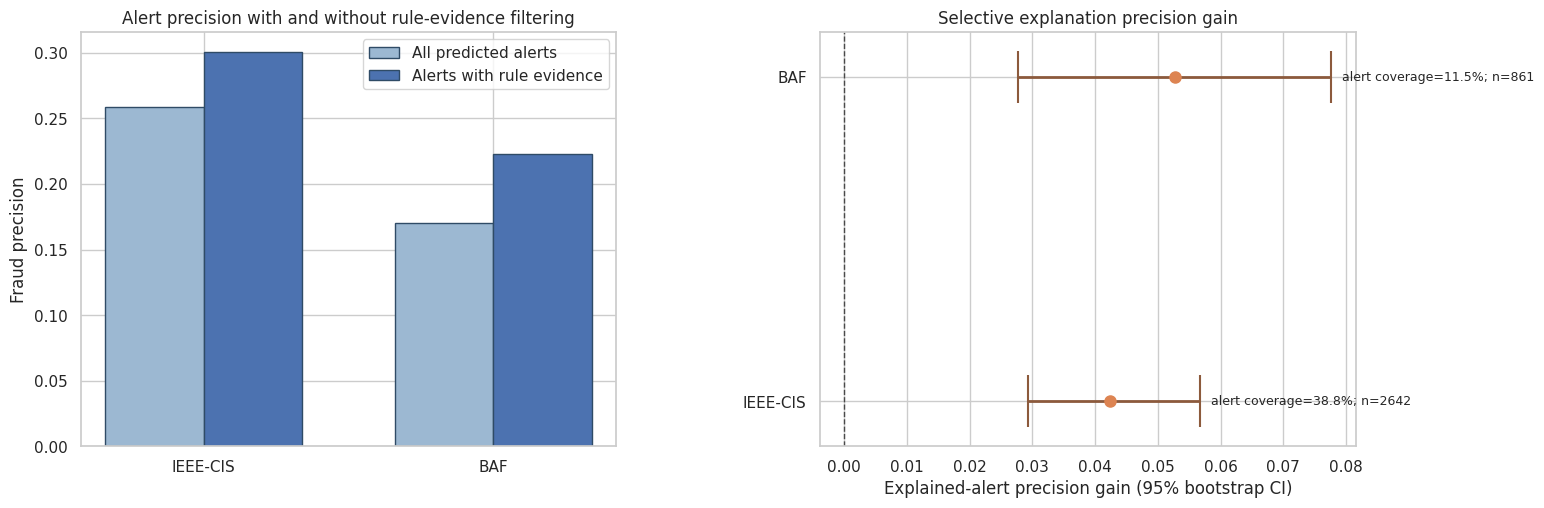

In [7]:
explanation_plot = explanations.copy()
x = np.arange(len(explanation_plot))
width = 0.34
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
axes[0].bar(
    x - width / 2, explanation_plot["all_alert_precision"], width,
    label="All predicted alerts", color="#9CB8D2", edgecolor="#2F4B66",
)
axes[0].bar(
    x + width / 2, explanation_plot["explained_alert_precision"], width,
    label="Alerts with rule evidence", color="#4C72B0", edgecolor="#2F4B66",
)
axes[0].set_xticks(x, explanation_plot["dataset"])
axes[0].set_ylabel("Fraud precision")
axes[0].set_title("Alert precision with and without rule-evidence filtering")
axes[0].legend(loc="upper right")

gain = explanation_plot["explained_alert_precision_gain"].to_numpy(float)
ci_low = explanation_plot["precision_gain_ci_low"].to_numpy(float)
ci_high = explanation_plot["precision_gain_ci_high"].to_numpy(float)
for position, (point, low, high) in enumerate(zip(gain, ci_low, ci_high)):
    if np.isfinite([point, low, high]).all():
        axes[1].hlines(position, low, high, color="#8C5A3C", linewidth=2)
        axes[1].plot(point, position, "o", markersize=8, color="#DD8452")
        axes[1].vlines([low, high], position - 0.08, position + 0.08, color="#8C5A3C")
    else:
        axes[1].text(0, position, "undefined", ha="center", va="center", fontsize=9)
axes[1].axvline(0, color="#4A4A4A", linestyle="--", linewidth=1)
axes[1].set_yticks(x, explanation_plot["dataset"])
axes[1].set_xlabel("Explained-alert precision gain (95% bootstrap CI)")
axes[1].set_title("Selective explanation precision gain")
for position, (_, row) in enumerate(explanation_plot.iterrows()):
    if np.isfinite(row["precision_gain_ci_high"]):
        axes[1].annotate(
            f"alert coverage={row['explanation_coverage_alerts']:.1%}; n={int(row['explained_alert_count'])}",
            (row["precision_gain_ci_high"], position), xytext=(8, 0),
            textcoords="offset points", va="center", fontsize=9,
        )
fig.subplots_adjust(left=0.10, right=0.95, bottom=0.14, top=0.88, wspace=0.38)
fig.savefig(output_dir / "figure_cross_dataset_explanation_evidence.png", dpi=180, bbox_inches="tight")
plt.show()

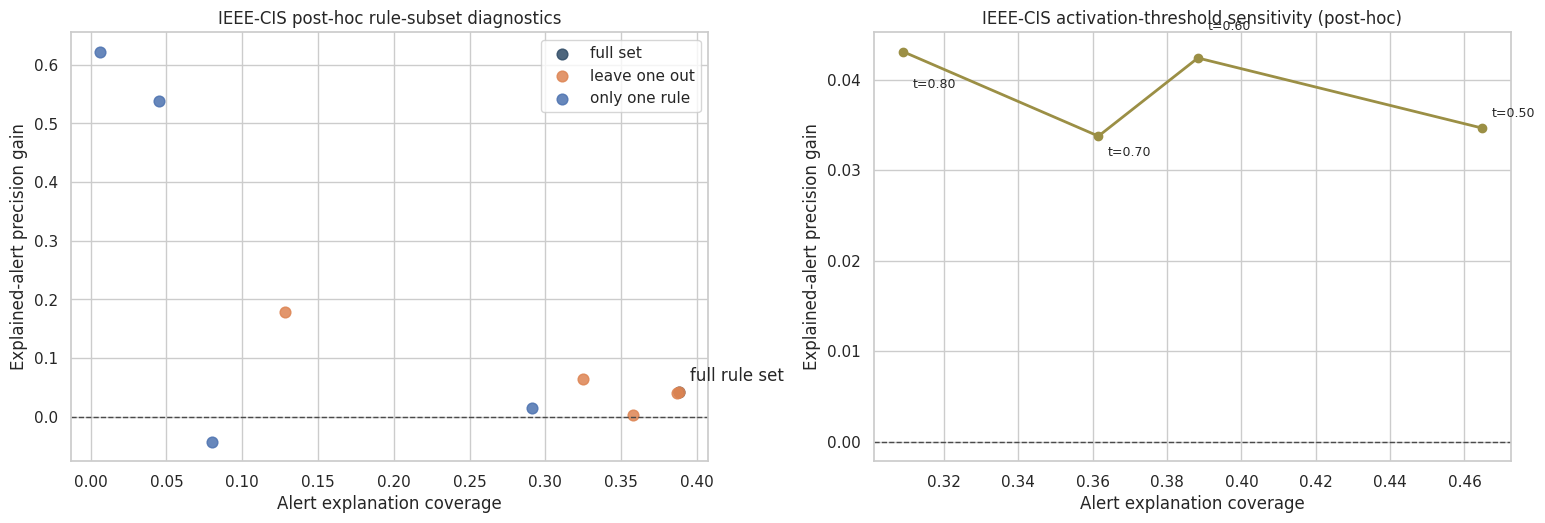

In [8]:
diagnostic = ablation.dropna(subset=["coverage_alerts", "precision_gain"]).copy()
diagnostic["family"] = np.select(
    [
        diagnostic["ablation"].str.startswith("only:"),
        diagnostic["ablation"].str.startswith("without:"),
        diagnostic["ablation"].eq("full_rule_set"),
        diagnostic["ablation"].eq("full_rule_set_sensitivity"),
    ],
    ["only one rule", "leave one out", "full set", "activation sensitivity"],
    default="other",
)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
palette = {
    "only one rule": "#4C72B0", "leave one out": "#DD8452",
    "full set": "#2F4B66", "activation sensitivity": "#9B8F45",
}
subset_diagnostics = diagnostic.loc[diagnostic["family"].isin(["only one rule", "leave one out", "full set"])]
for family, group in subset_diagnostics.groupby("family"):
    axes[0].scatter(
        group["coverage_alerts"], group["precision_gain"],
        label=family, color=palette[family], s=60, alpha=0.85,
    )
full = diagnostic.loc[diagnostic["ablation"] == "full_rule_set"].iloc[0]
axes[0].annotate("full rule set", (full["coverage_alerts"], full["precision_gain"]),
                 xytext=(8, 8), textcoords="offset points")
axes[0].axhline(0, color="#4A4A4A", linestyle="--", linewidth=1)
axes[0].set_xlabel("Alert explanation coverage")
axes[0].set_ylabel("Explained-alert precision gain")
axes[0].set_title("IEEE-CIS post-hoc rule-subset diagnostics")
axes[0].legend(loc="best")

sensitivity = diagnostic.loc[diagnostic["family"] == "activation sensitivity"].sort_values("activation_threshold")
axes[1].plot(
    sensitivity["coverage_alerts"], sensitivity["precision_gain"],
    marker="o", color=palette["activation sensitivity"], linewidth=2,
)
label_offsets = [(7, 8), (7, 20), (7, -14), (7, -26)]
for label_index, (_, row) in enumerate(sensitivity.iterrows()):
    axes[1].annotate(
        f"t={row['activation_threshold']:.2f}",
        (row["coverage_alerts"], row["precision_gain"]),
        xytext=label_offsets[label_index % len(label_offsets)],
        textcoords="offset points", fontsize=9,
    )
axes[1].axhline(0, color="#4A4A4A", linestyle="--", linewidth=1)
axes[1].set_xlabel("Alert explanation coverage")
axes[1].set_ylabel("Explained-alert precision gain")
axes[1].set_title("IEEE-CIS activation-threshold sensitivity (post-hoc)")
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.14, top=0.88, wspace=0.26)
fig.savefig(output_dir / "figure_ieee_ablation_coverage_precision_tradeoff.png", dpi=180, bbox_inches="tight")
plt.show()

## Thesis evidence matrix

In [9]:
ieee_explanation = explanations.loc[explanations["dataset"] == "IEEE-CIS"].iloc[0]
baf_explanation = explanations.loc[explanations["dataset"] == "BAF"].iloc[0]
ieee_reference = reference_rows.loc[reference_rows["dataset"] == "IEEE-CIS"].iloc[0]
baf_reference = reference_rows.loc[reference_rows["dataset"] == "BAF"].iloc[0]

def enrichment_status(row):
    values = row[[
        "explained_alert_precision_gain", "precision_gain_ci_low", "precision_gain_ci_high",
    ]].to_numpy(float)
    if not np.isfinite(values).all():
        return "undefined"
    if float(row["precision_gain_ci_low"]) > 0:
        return "positive"
    if float(row["precision_gain_ci_high"]) < 0:
        return "negative"
    return "inconclusive (CI includes zero)"

enrichment = {
    "IEEE-CIS": enrichment_status(ieee_explanation),
    "BAF": enrichment_status(baf_explanation),
}
positive_datasets = [name for name, status in enrichment.items() if status == "positive"]
if len(positive_datasets) == len(enrichment):
    rq3_supported_claim = (
        "Positive alert enrichment from rule-evidence filtering is supported on both evaluated benchmarks."
    )
elif positive_datasets:
    remaining = [name for name in enrichment if name not in positive_datasets]
    rq3_supported_claim = (
        f"Positive enrichment is supported for {', '.join(positive_datasets)}, but cross-dataset "
        f"replication is not established because {', '.join(remaining)} is "
        f"{', '.join(enrichment[name] for name in remaining)}."
    )
else:
    status_text = "; ".join(f"{name}: {status}" for name, status in enrichment.items())
    rq3_supported_claim = (
        f"The current intervals do not establish positive alert enrichment on either benchmark ({status_text})."
    )
evidence_matrix = pd.DataFrame([
    {
        "research_question": "RQ1 - Leakage-aware fraud prediction",
        "observed_evidence": (
            f"IEEE {ieee_reference['model']} raw PR-AUC={ieee_reference['raw_pr_auc_mean']:.4f}; "
            f"BAF {baf_reference['model']} raw PR-AUC={baf_reference['raw_pr_auc_mean']:.4f}."
        ),
        "supported_claim": "The locked temporal protocol yields traceable predictive measurements and validation-selected frozen references on both benchmarks.",
        "claim_boundary": "No SOTA, universal superiority, or production-readiness claim.",
    },
    {
        "research_question": "RQ2 - Fuzzy knowledge representation",
        "observed_evidence": "Train-fitted fuzzy rules, fitted thresholds, per-rule coverage/lift and balanced KB satisfaction are reported.",
        "supported_claim": "Domain/data-informed hypotheses can be represented as an auditable fuzzy-rule layer.",
        "claim_boundary": "LTN-inspired diagnostic, not an end-to-end co-trained LTN predictor.",
    },
    {
        "research_question": "RQ3 - Selective alert audit value",
        "observed_evidence": (
            f"Precision gain: IEEE {ieee_explanation['explained_alert_precision_gain']:.3f} "
            f"(CI {ieee_explanation['precision_gain_ci_low']:.3f} to {ieee_explanation['precision_gain_ci_high']:.3f}); "
            f"BAF {baf_explanation['explained_alert_precision_gain']:.3f} "
            f"(CI {baf_explanation['precision_gain_ci_low']:.3f} to {baf_explanation['precision_gain_ci_high']:.3f})."
        ),
        "supported_claim": rq3_supported_claim,
        "claim_boundary": "Association/enrichment, not causal or model-faithful explanation.",
    },
    {
        "research_question": "RQ4 - Coverage-precision trade-off",
        "observed_evidence": "Rule-subset and activation-threshold diagnostics expose changes in alert coverage and explained-alert precision.",
        "supported_claim": "Post-hoc diagnostics quantify how explanation coverage and precision gain vary across rule subsets and activation thresholds.",
        "claim_boundary": "Locked-test ablation is post-hoc and cannot select a new unbiased final rule set.",
    },
    {
        "research_question": "RQ5 - Cross-dataset applicability and reproducibility",
        "observed_evidence": "Frozen checksums, split alignment, lineage manifests and BAF-specific replication are verified.",
        "supported_claim": "The same audited pipeline is reproducibly executed on a second benchmark with dataset-specific rules and models.",
        "claim_boundary": "Not transfer of the same model/rules and not external institutional validation.",
    },
])
display(evidence_matrix)
evidence_matrix.to_csv(output_dir / "table_thesis_evidence_matrix.csv", index=False)

,research_question,observed_evidence,supported_claim,claim_boundary
0,RQ1 - Leakage-aware fraud prediction,IEEE xgboost raw PR-AUC=0.4557; BAF lightgbm raw PR-AUC=0.1890.,The locked temporal protocol yields traceable predictive measurements and validation-selected frozen references on b...,"No SOTA, universal superiority, or production-readiness claim."
1,RQ2 - Fuzzy knowledge representation,"Train-fitted fuzzy rules, fitted thresholds, per-rule coverage/lift and balanced KB satisfaction are reported.",Domain/data-informed hypotheses can be represented as an auditable fuzzy-rule layer.,"LTN-inspired diagnostic, not an end-to-end co-trained LTN predictor."
2,RQ3 - Selective alert audit value,Precision gain: IEEE 0.042 (CI 0.029 to 0.057); BAF 0.053 (CI 0.028 to 0.078).,Positive alert enrichment from rule-evidence filtering is supported on both evaluated benchmarks.,"Association/enrichment, not causal or model-faithful explanation."
3,RQ4 - Coverage-precision trade-off,Rule-subset and activation-threshold diagnostics expose changes in alert coverage and explained-alert precision.,Post-hoc diagnostics quantify how explanation coverage and precision gain vary across rule subsets and activation th...,Locked-test ablation is post-hoc and cannot select a new unbiased final rule set.
4,RQ5 - Cross-dataset applicability and reproducibility,"Frozen checksums, split alignment, lineage manifests and BAF-specific replication are verified.",The same audited pipeline is reproducibly executed on a second benchmark with dataset-specific rules and models.,Not transfer of the same model/rules and not external institutional validation.


## Takeaways

In [10]:
display(reference_rows[[
    "dataset", "model", "raw_pr_auc_mean", "raw_pr_auc_std",
    "test_prevalence", "pr_auc_over_prevalence", "fbeta_mean", "brier_mean", "ece_mean",
]].round(4))
display(Markdown(
    "- Reference models above come from frozen manifests selected on validation; Notebook 08 never reselects from test.\n"
    "- Raw PR-AUC supports ranking; calibrated probabilities support Brier/ECE/NLL and locked-threshold decisions.\n"
    "- The paired bootstrap is row-level uncertainty for the frozen reference seed, while three-seed SD is descriptive run variability.\n"
    f"- Rule-evidence result: {rq3_supported_claim}\n"
    "- BAF supports framework replication with BAF-specific rules, not model/rule transfer, causal explanation, or production generalization."
))

,dataset,model,raw_pr_auc_mean,raw_pr_auc_std,test_prevalence,pr_auc_over_prevalence,fbeta_mean,brier_mean,ece_mean
0,IEEE-CIS,xgboost,0.4557,0.0039,0.0348,13.0918,0.4628,0.0244,0.0076
1,BAF,lightgbm,0.1890,0.0019,0.0140,13.4653,0.3336,0.0125,0.0026


- Reference models above come from frozen manifests selected on validation; Notebook 08 never reselects from test.
- Raw PR-AUC supports ranking; calibrated probabilities support Brier/ECE/NLL and locked-threshold decisions.
- The paired bootstrap is row-level uncertainty for the frozen reference seed, while three-seed SD is descriptive run variability.
- Rule-evidence result: Positive alert enrichment from rule-evidence filtering is supported on both evaluated benchmarks.
- BAF supports framework replication with BAF-specific rules, not model/rule transfer, causal explanation, or production generalization.